# CSR Setup

A data analysis of the use case 'not sharing dependencies between remotes' on the CSR setup. 

CSR = Client Side Rendering using Angular 18.3, Java 21, Apache Wicket 10 and Native Federation

In [1]:
import pandas as pd;
import numpy as np;
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
import scipy.stats as stats

plt.rcParams.update({'font.size': 14})
pd.set_option('display.float_format', lambda x: '%.2f' % x)
path = '../../../../playwright/results/core-web-vitals/testrun-9/'

def graph_row(plot_func, datasets, height=3, width=20):
    cols = len(datasets)
    fig, axes = plt.subplots(ncols=cols, figsize=(width, height))
    plt.subplots_adjust(hspace=0.3, wspace=0.3, top=0.95, bottom=0.05)
    for x, (name, dataset) in enumerate(datasets.items()):
        plot_func(dataset, axes[x], idx=x)
        axes[x].set_title(name)
    return plt

def graph_grid(plot_func, datasets, features, height=4, width=20):
    fig, axes = plt.subplots(ncols=len(datasets), nrows=len(features), figsize=(width, height*len(features)))
    plt.subplots_adjust(hspace=0.3, wspace=0.3, top=0.95, bottom=0.05)
    for y, f in enumerate(features):
        for x, (name, dataset) in enumerate(datasets.items()):
            plot_func(dataset, axes[y,x], idx=x+y, d=name, f=f)
            axes[y,x].set_title(name)
    return plt

def detect_outliers(_df, _features, contamination=0.1):
    clf = IsolationForest(contamination=contamination, random_state=42)
    outliers = clf.fit_predict(_df[_features])
    return outliers == 1

In [2]:
features = ['navTime', 'totalTime', 'lcp', 'fcp', 'ttfb', 'tbt', 'tti', 'longestTask', 'longTasks', 'nf:init', 'nf:config','nf:loaded']

dirty_dfs = {
    'default': pd.read_csv(f'{path}results-csr.csv', sep=',')[5:],
    'throttled': pd.read_csv(f'{path}results-csr-throttled.csv', sep=',')[5:],
    'heavy': pd.read_csv(f'{path}results-csr-throttled-heavy.csv', sep=',')[5:],
}

## Dataset cleanup + oulier removal

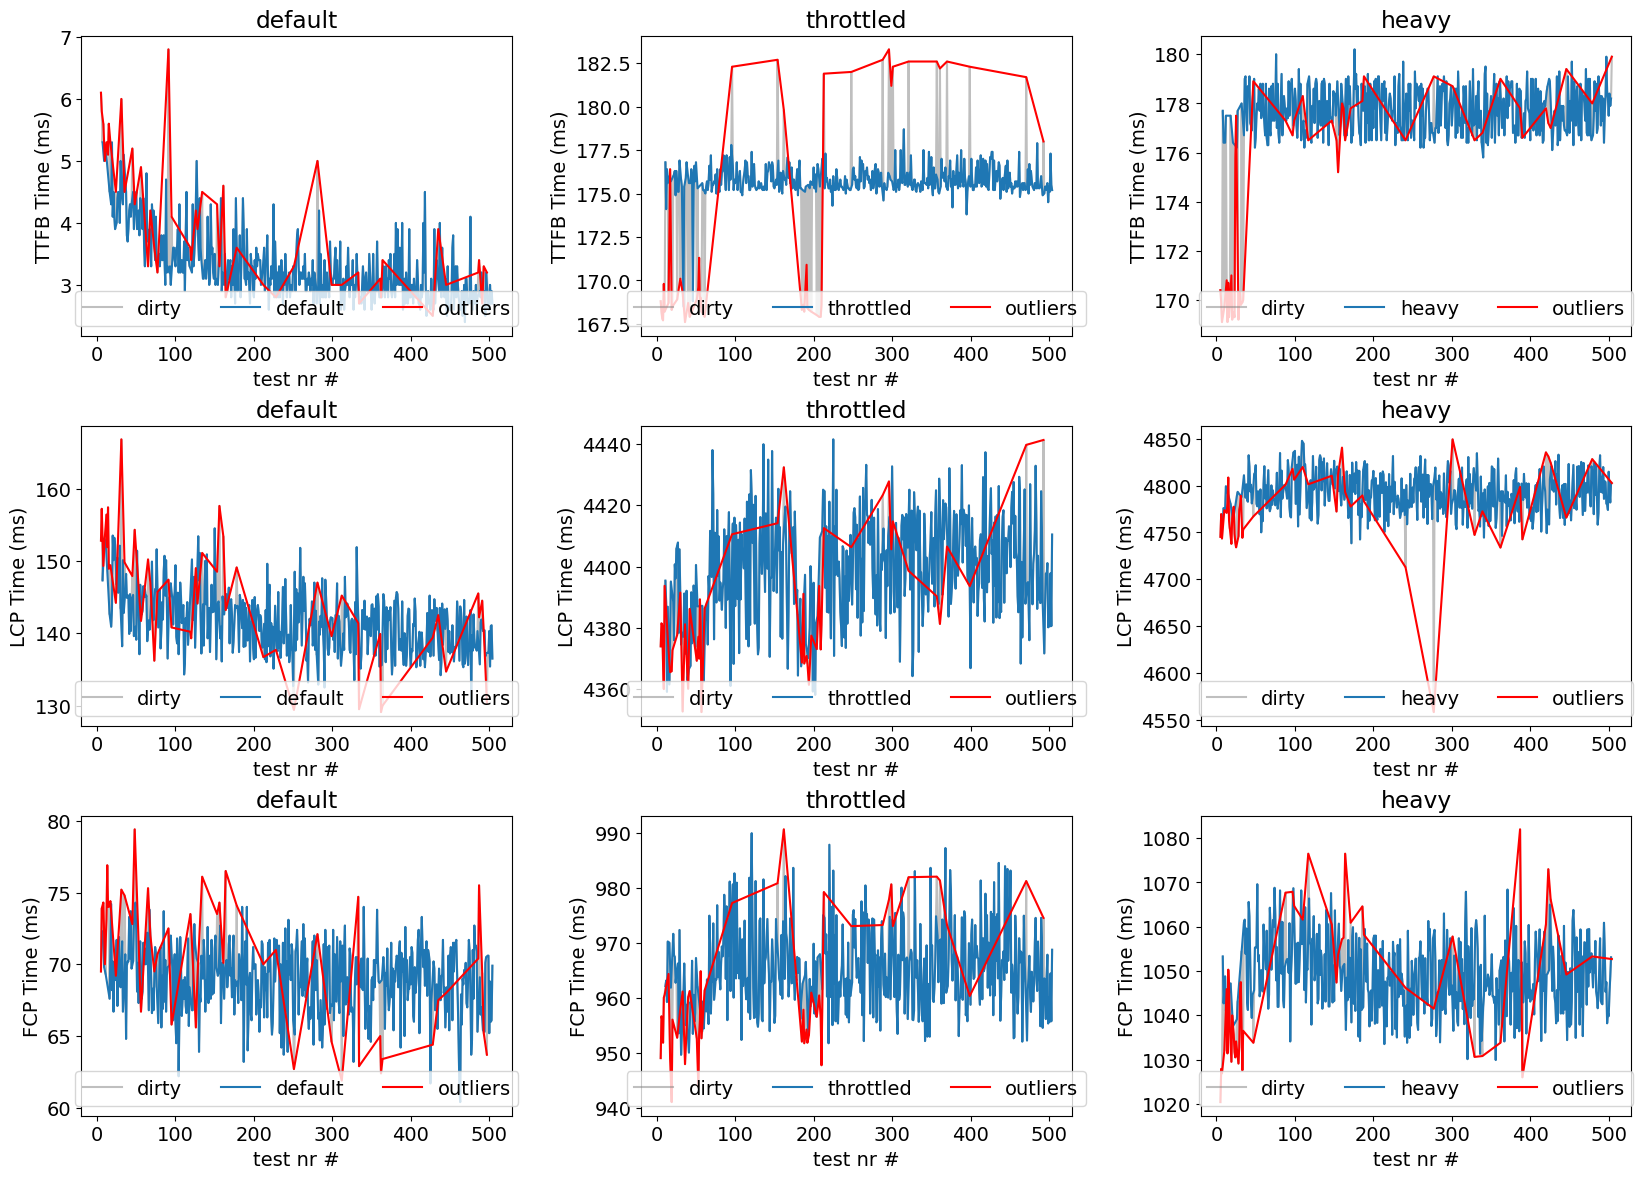

In [3]:
masks = {}
dfs = {}
target_features = ['navTime', 'totalTime', 'lcp', 'fcp', 'ttfb']

for name, _df in dirty_dfs.items():
    mask = detect_outliers(_df, target_features)
    masks[name] = mask
    dfs[name] = _df[mask].copy()

def plot_outliers(_df, axes, idx, d, f):
    axes.plot(_df[f], label='dirty', color='gray', alpha=0.5)
    axes.plot(_df[f][masks[d]], label=d)
    axes.plot(_df[f][~masks[d]], label='outliers', color='red')

    axes.set_title(d)
    axes.set_ylabel(f'{f.upper()} Time (ms)') 
    axes.set_xlabel('test nr #') 
    axes.legend(loc='lower center', ncols=3)

graph_grid(plot_outliers, dirty_dfs, features=['ttfb','lcp', 'fcp'])
plt.tight_layout()
plt.show()

## Performance over time

x = Cycles over time (sequential)

y = Performance marks over time (each marking the timestamp when finished)

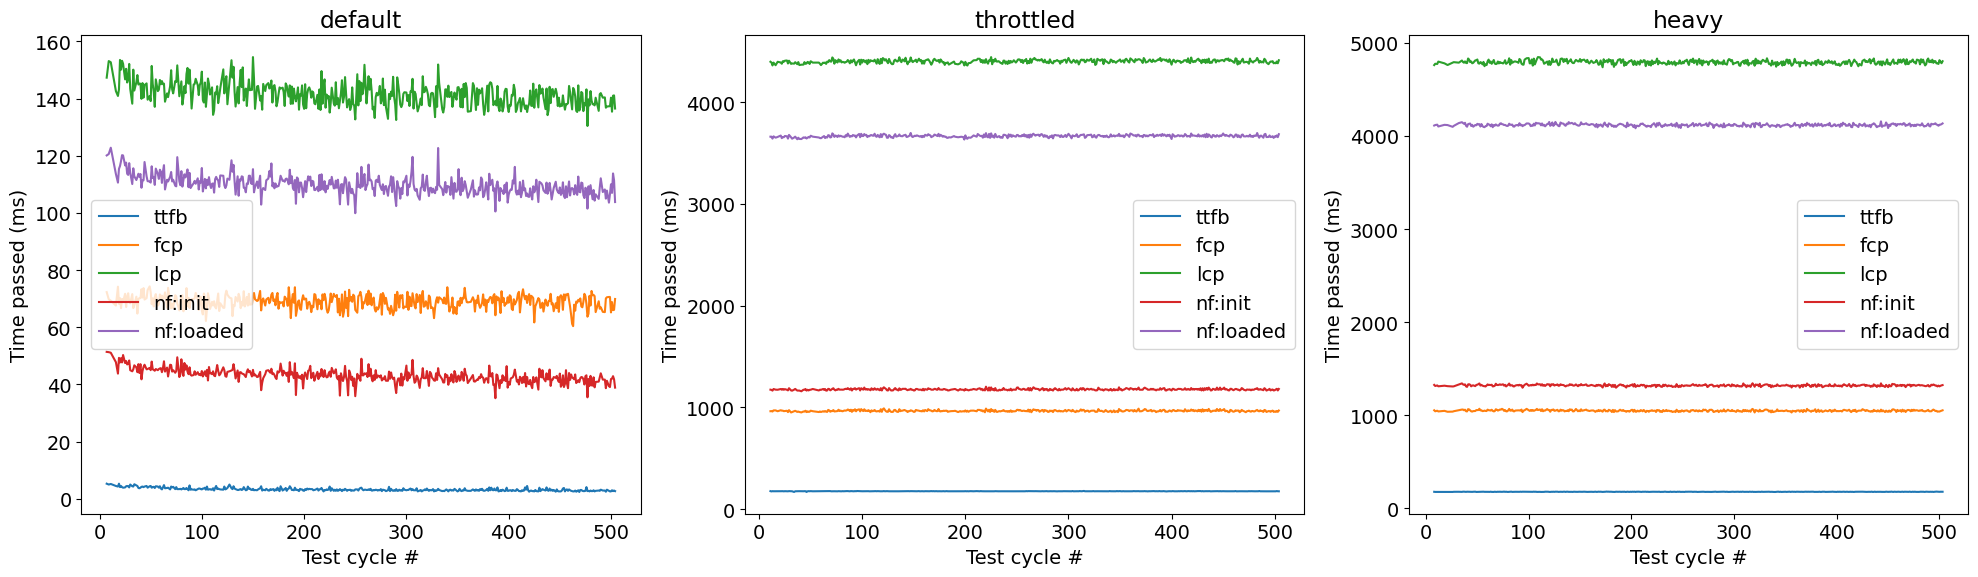

In [4]:
def plot_line(dataset, loc, idx):
    for t in ['ttfb', 'fcp', 'lcp', 'nf:init', 'nf:loaded']:
        loc.plot(dataset[t], label=t)
    loc.set_xlabel('Test cycle #')
    loc.set_ylabel('Time passed (ms)')
    loc.legend()

graph_row(plot_line, dfs, height=6)
plt.tight_layout()
plt.show()

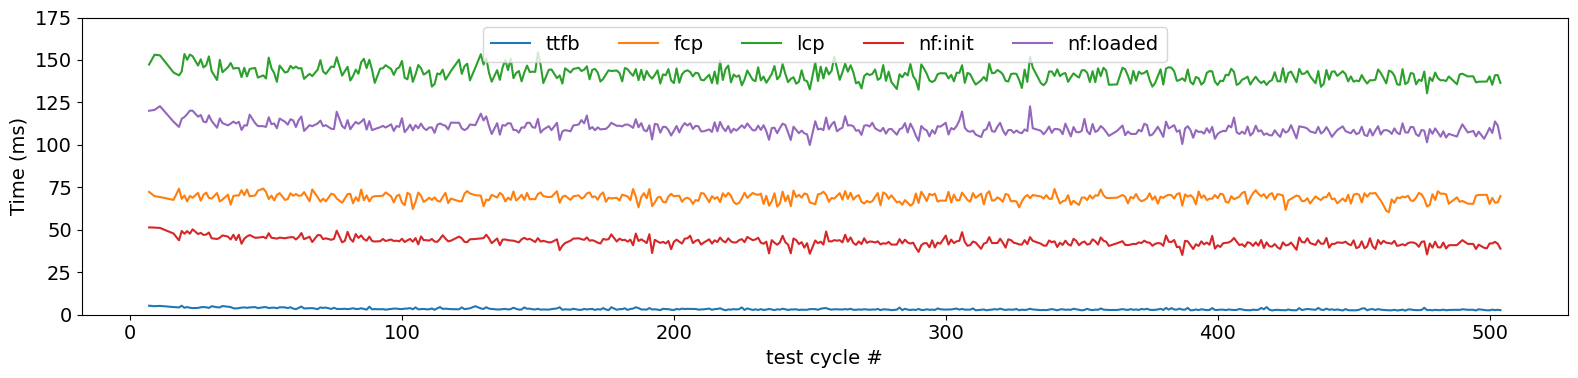

In [5]:
plt.figure(figsize=(16, 4))

for t in ['ttfb', 'fcp', 'lcp', 'nf:init', 'nf:loaded']:
    plt.plot(dfs['default'][t], label=t)
plt.xlabel('test cycle #')
plt.ylabel('Time (ms)')
plt.legend(loc='upper center', ncols=5)
plt.ylim(bottom=0, top=175)
plt.margins(y=0.1)

plt.tight_layout()
plt.show()

## Comparison of JavaScript performance between contexts. 

tbt = total blocking time

longestTask = duration of the longest task. 

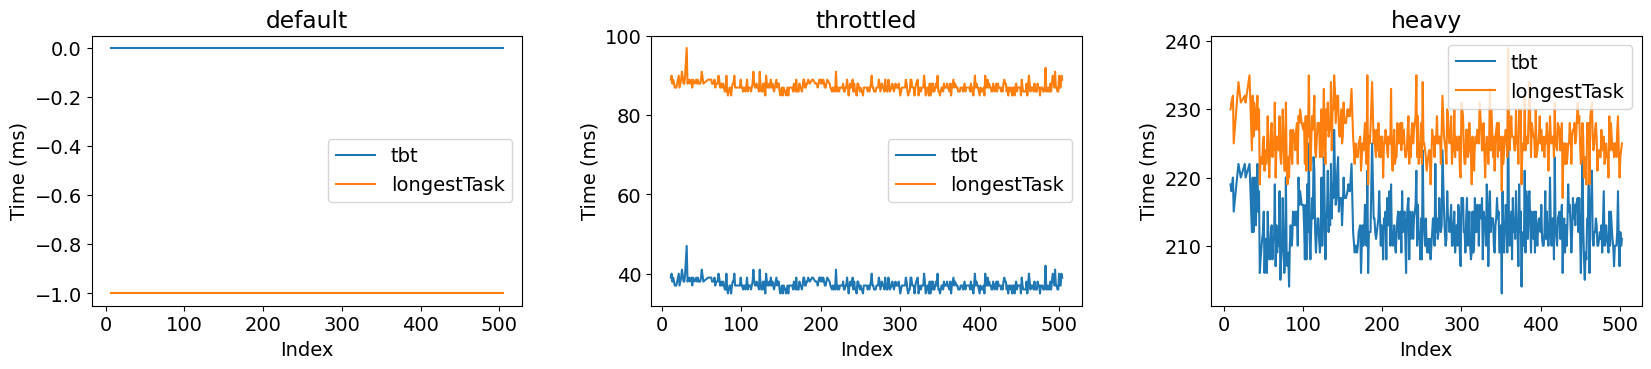

In [6]:
def plot_line(dataset, loc, idx):
    for t in ['tbt', 'longestTask']:
        loc.plot(dataset[t], label=t)
    loc.set_xlabel('Index')
    loc.set_ylabel('Time (ms)')
    loc.legend()

graph_row(plot_line, dfs)
plt.show()

## 75th quantile of all performance metrics

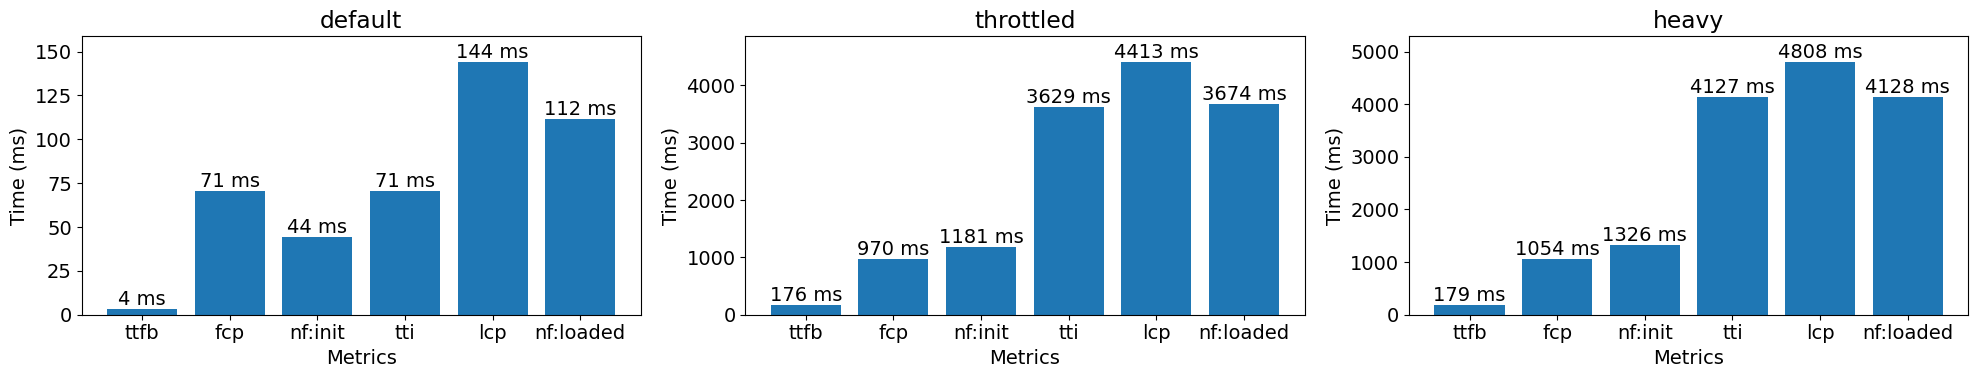

In [7]:
def plot_timeline_bars(dataset, loc, idx):
    metrics = ['ttfb', 'fcp', 'nf:init', 'tti', 'lcp', 'nf:loaded']
    quantiles = [dataset[t].quantile(0.75) for t in metrics]
    bars = loc.bar(metrics, quantiles, label='75th percentile')
    loc.set_xlabel('Metrics')
    loc.set_ylabel('Time (ms)')
    
    for bar in bars:
        height = bar.get_height()
        loc.text(bar.get_x() + bar.get_width() / 2.0, height, f'{height:.0f} ms', ha='center', va='bottom')
    
    loc.set_ylim(0, max(quantiles) * 1.1)

graph_row(plot_timeline_bars, dfs, height=4)
plt.tight_layout()
plt.show()

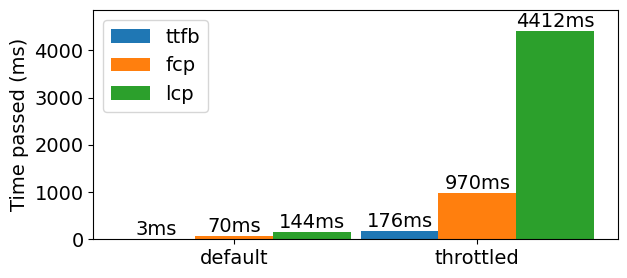

In [17]:
metrics = ['ttfb', 'fcp', 'lcp']
contexts = ['default', 'throttled']

fig, ax = plt.subplots(figsize=(6.5, 3))
x = np.arange(len(contexts))
width = 0.32

max_height = 0
for i, m in enumerate(metrics):
    values = [dfs[ctx][m].quantile(0.75) for ctx in contexts]
    max_height = max(max_height, max(values))
    bars = ax.bar(x + i*width, values, width, label=m)
    
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}ms',
                ha='center', va='bottom')

ax.set_ylim(0, max_height * 1.1)

ax.set_ylabel('Time passed (ms)')
ax.set_xticks(x + width)
ax.set_xticklabels(contexts)
ax.legend()

plt.tight_layout()
plt.show()


In [9]:
dfs['default'].describe()

,idx,navTime,totalTime,lcp,fcp,ttfb,tbt,tti,longTasks,longestTask,nf:init,nf:config,nf:loaded,error
count,450.00,450.00,450.00,450.00,450.00,450.00,450.00,450.00,450.00,450.00,450.00,450.00,450.00,0.00
mean,263.01,9.07,76.30,141.55,68.92,3.28,0.00,68.92,0.00,-1.00,43.10,49.31,109.85,NaN
std,140.26,2.74,8.50,4.16,2.39,0.54,0.00,2.39,0.00,0.00,2.38,2.86,3.30,NaN
min,8.00,7.00,57.00,130.40,60.40,2.40,0.00,60.40,0.00,-1.00,35.20,40.10,99.90,NaN
25%,144.25,8.00,72.00,138.02,67.20,2.90,0.00,67.20,0.00,-1.00,41.80,47.60,107.90,NaN
50%,264.50,8.00,79.00,141.65,69.20,3.10,0.00,69.20,0.00,-1.00,43.00,49.10,109.50,NaN
75%,384.75,9.00,82.00,144.27,70.67,3.50,0.00,70.67,0.00,-1.00,44.48,50.70,111.60,NaN
max,505.00,24.00,93.00,154.50,74.30,5.30,0.00,74.30,0.00,-1.00,51.40,64.80,122.80,NaN


In [10]:
dfs['throttled'].describe()

,idx,navTime,totalTime,lcp,fcp,ttfb,tbt,tti,longTasks,longestTask,nf:init,nf:config,nf:loaded,error
count,450.00,450.00,450.00,450.00,450.00,450.00,450.00,450.00,450.00,450.00,450.00,450.00,450.00,0.00
mean,266.66,170.38,3653.57,4399.65,965.46,175.77,37.24,3619.52,1.00,87.24,1176.26,1516.52,3665.96,NaN
std,141.17,0.94,20.87,16.61,7.58,0.82,1.34,13.35,0.00,1.34,7.66,10.33,11.67,NaN
min,12.00,163.00,3600.00,4358.20,949.60,168.50,35.00,3576.90,1.00,85.00,1157.90,1486.70,3631.30,NaN
25%,142.25,170.00,3636.00,4388.10,960.10,175.30,36.00,3609.90,1.00,86.00,1172.50,1509.10,3657.60,NaN
50%,269.50,170.00,3654.00,4399.70,964.20,175.60,37.00,3619.75,1.00,87.00,1174.10,1516.20,3666.00,NaN
75%,389.75,171.00,3671.00,4412.67,970.20,176.20,38.00,3628.97,1.00,88.00,1181.30,1523.88,3674.37,NaN
max,505.00,175.00,3698.00,4441.40,989.90,178.70,47.00,3651.40,1.00,97.00,1203.00,1545.50,3695.70,NaN


In [11]:
dfs['heavy'].describe()

,idx,navTime,totalTime,lcp,fcp,ttfb,tbt,tti,longTasks,longestTask,nf:init,nf:config,nf:loaded,error
count,450.00,450.00,450.00,450.00,450.00,450.00,450.00,450.00,450.00,450.00,450.00,450.00,450.00,0.00
mean,266.47,180.26,4134.29,4792.50,1048.92,177.72,213.22,4117.96,3.00,225.76,1319.92,1668.14,4118.29,NaN
std,139.01,1.08,13.56,21.01,8.01,0.93,4.14,13.15,0.00,3.31,9.05,10.42,13.20,NaN
min,9.00,177.00,4097.00,4738.40,1029.90,175.80,203.00,4083.40,3.00,217.00,1296.10,1641.40,4083.40,NaN
25%,145.25,180.00,4125.00,4777.20,1043.13,176.90,210.00,4108.92,3.00,224.00,1313.10,1661.60,4109.20,NaN
50%,267.50,180.00,4134.00,4793.05,1048.75,177.70,213.00,4117.60,3.00,225.00,1319.50,1669.75,4117.95,NaN
75%,384.75,181.00,4144.00,4808.22,1054.27,178.60,215.75,4127.30,3.00,228.00,1326.30,1677.07,4127.80,NaN
max,504.00,183.00,4174.00,4847.80,1069.60,180.20,232.00,4156.70,3.00,239.00,1343.20,1693.00,4157.40,NaN


## Performance difference First Contentful Paint (75th quantile)

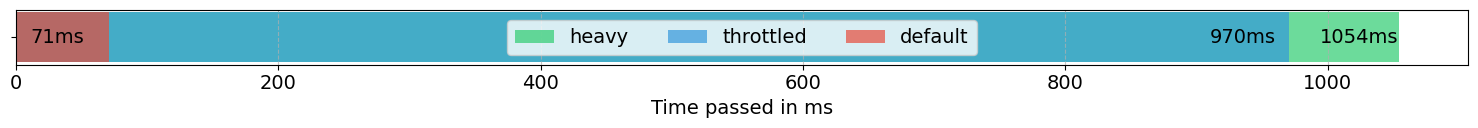

In [12]:
fig, ax = plt.subplots(figsize=(15, 1.5))

fcp_values = [df['fcp'].quantile(0.75) for df in dfs.values()]

bar_height = 0.25
colors = ['#2ecc71', '#3498db', '#e74c3c']

bars = []
for i, (name, value) in enumerate(zip(reversed(dfs.keys()), reversed(fcp_values))):
    bar = ax.barh(0.5, value, height=bar_height, 
                 label=name, color=colors[i], alpha=0.7)
    bars.append(bar)

ax.set_yticks([0.5])
ax.set_yticklabels([''])
ax.set_xlabel('Time passed in ms')

ax.grid(True, axis='x', linestyle='--', alpha=0.7)

for i, bar in enumerate(bars):
    width = bar[0].get_width()
    ax.text(width - 60, bar[0].get_y() + bar[0].get_height()/2, 
            f'{fcp_values[-(i+1)]:.0f}ms', 
            va='center')

ax.legend(loc='lower center', ncols=3)

plt.tight_layout()

plt.show()

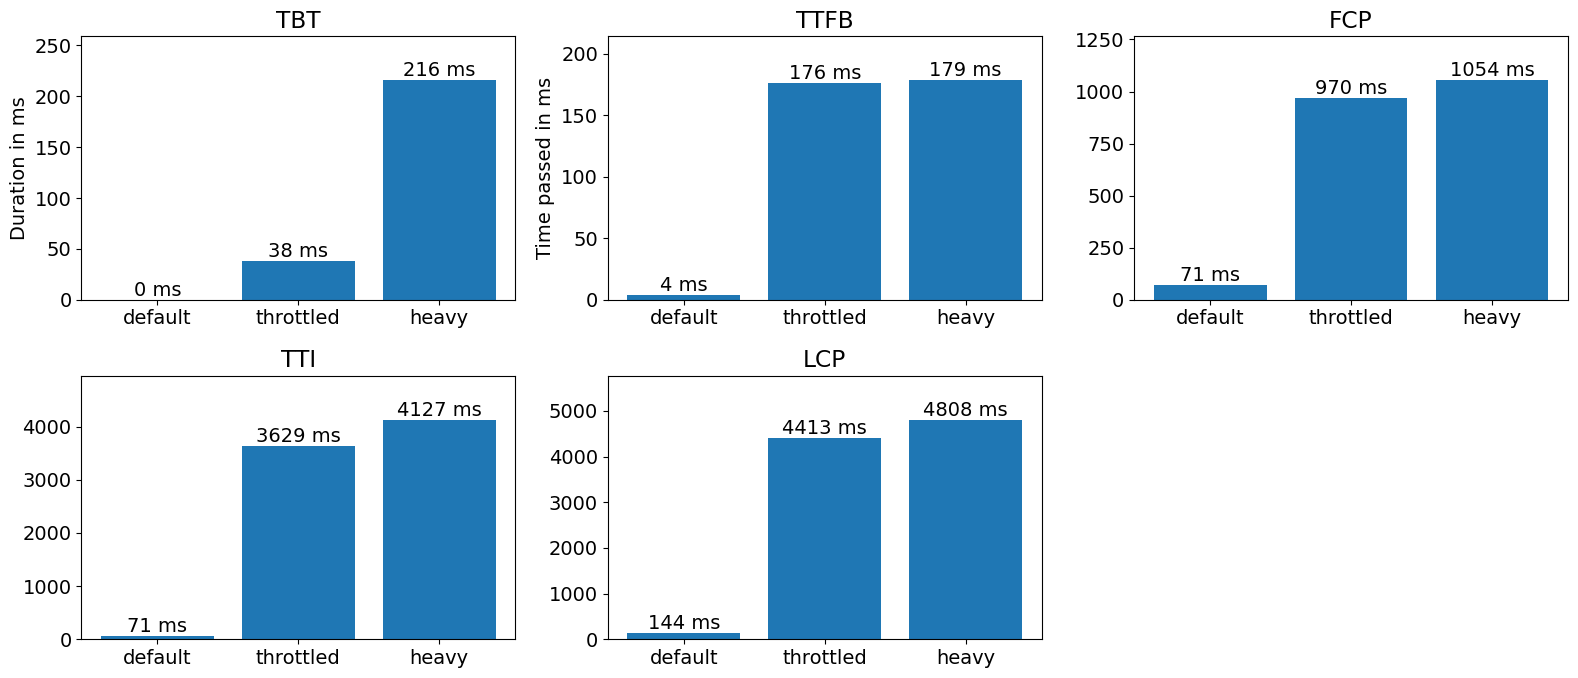

In [13]:
features = ['tbt','ttfb', 'fcp', 'tti', 'lcp']
fig, axes = plt.subplots(ncols=3, nrows=2, figsize=(16, 7))
plt.subplots_adjust(hspace=0.3, wspace=0.3, top=0.95, bottom=0.05)
axes = axes.flatten()

for idx, feature in enumerate(features):
    percentiles = {d: dfs[d][feature].quantile(0.75) for d in dfs.keys()}
    bars = axes[idx].bar(percentiles.keys(), percentiles.values())
    
    max_height = max(percentiles.values())
    axes[idx].set_ylim(0, max_height * 1.2)
    
    for bar in bars:
        height = bar.get_height()
        label = f'{int(round(height, 0))} ms'
        axes[idx].text(bar.get_x() + bar.get_width()/2., height, label, ha='center', va='bottom')
    
    axes[idx].set_title(feature.upper())
    if idx == 0:
        axes[idx].set_ylabel('Duration in ms')
    if idx == 1:
        axes[idx].set_ylabel('Time passed in ms')


for ax in axes[len(target_features):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

## Distribution of performance metrics

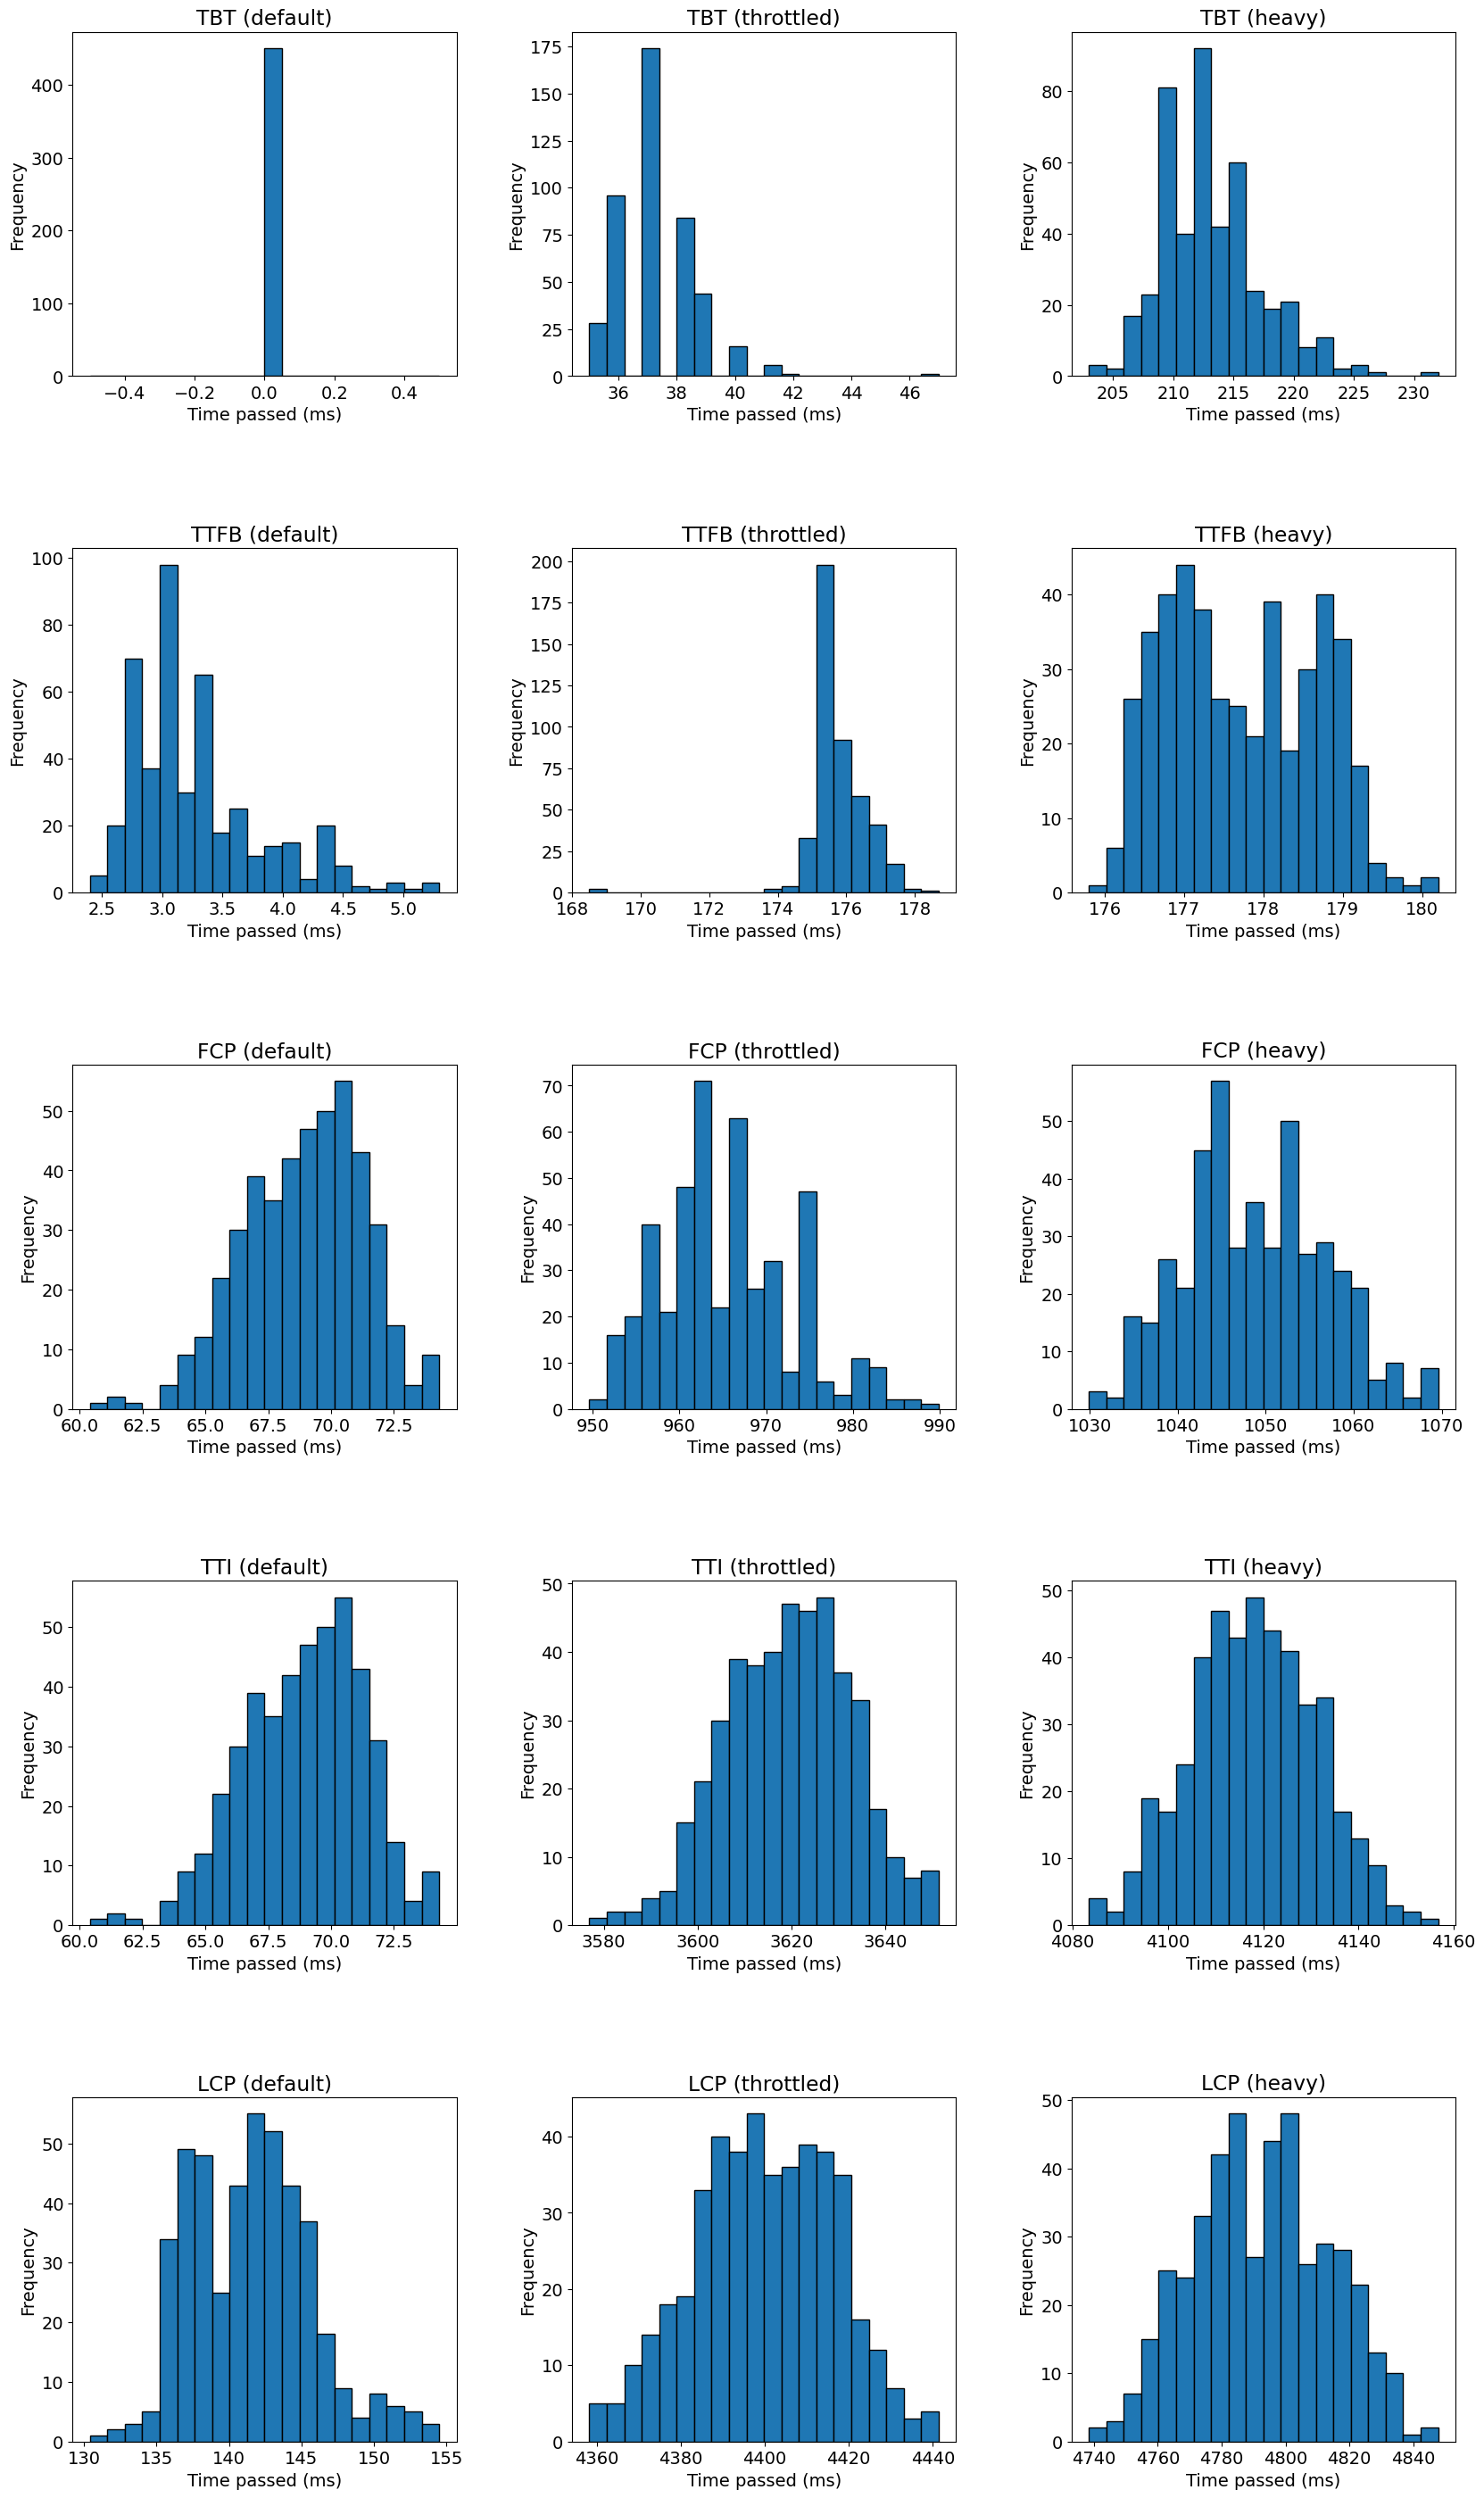

In [14]:
target_features = ['tbt', 'ttfb', 'fcp', 'tti', 'lcp']

fig, axes = plt.subplots(nrows=len(target_features), ncols=len(dfs.keys()), figsize=(20, 6*len(target_features)))
plt.subplots_adjust(hspace=0.5, wspace=0.3, top=0.95, bottom=0.05)

for y, f in enumerate(target_features):
    for x, d in enumerate(dfs.keys()):
        axes[y, x].hist(dfs[d][f], bins=20,  edgecolor='black')
        axes[y, x].set_title(f'{f.upper()} ({d})')
        axes[y, x].set_xlabel('Time passed (ms)')
        axes[y, x].set_ylabel('Frequency')

plt.show()

## Details dataset
This dataset kept track of the specific metrics, like the start and end time of the LCP. 

The start-time is defined by the timestamp where the image arrived to the browser (download ready). 

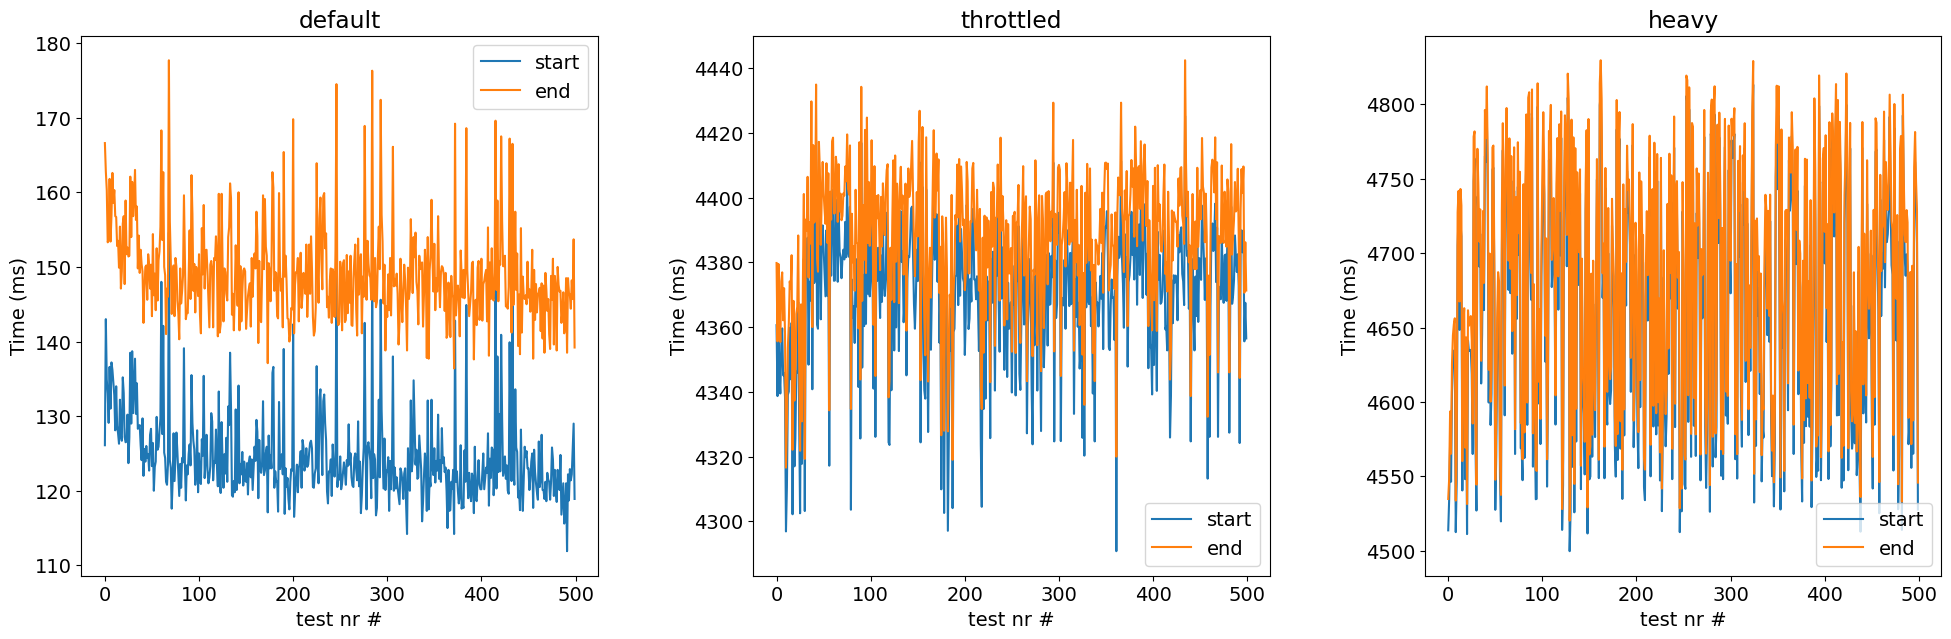

In [15]:
det_df = pd.read_csv(f'{path}details/details-csr.csv', sep=',')
det_df_t = pd.read_csv(f'{path}details/details-csr-throttled.csv', sep=',')
det_df_ht = pd.read_csv(f'{path}details/details-csr-throttled-heavy.csv', sep=',')

lcp_dfs = {
  'default': det_df[(det_df['type'] == 'LCP') & (det_df['idx'] > 5)].reset_index(drop=True),
  'throttled': det_df_t[(det_df_t['type'] == 'LCP') & (det_df_t['idx'] > 5)].reset_index(drop=True),
  'heavy': det_df_ht[(det_df_ht['type'] == 'LCP') & (det_df_ht['idx'] > 5)].reset_index(drop=True),
}
lcp_features = ['start','end','duration','name','element','url','id']


def plot_lcp_line(_df, loc, idx):
  for f in ['start', 'end']:
    loc.plot(_df[f], label=f)
  
  loc.set_title("LCP")
  loc.set_ylabel('Time (ms)')
  loc.set_xlabel('test nr #')
  loc.legend()

graph_row(plot_lcp_line, lcp_dfs, height=6, width=24)
plt.show()